In [27]:
import nltk
import pandas as pd
import os
import string

nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer

import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np

from IPython.display import display


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/silvycollin/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/silvycollin/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/silvycollin/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [3]:
folder_path = "story_segments/"


In [5]:
# Load the dataset
df = pd.read_csv("imageability_Cortese2004.tsv", sep="\t")  # replace with your file path



In [7]:
df

,item,rt,sd_rt,num,rating,sd_rating,toglia
0,ace,1363.0,654.0,29,4.5,2.7,NaN
1,ache,1439.7,640.3,30,3.8,2.3,NaN
2,act,1388.6,787.7,31,3.5,2.3,4.31
3,ad,1237.3,812.4,28,4.1,2.6,NaN
4,add,1287.3,606.3,30,3.3,2.2,NaN
...,...,...,...,...,...,...,...
2995,zing,1128.3,814.6,30,2.3,1.9,NaN
2996,zip,1318.8,679.4,29,5.1,2.2,NaN
2997,zone,1227.5,871.1,31,4.1,2.5,4.56
2998,zoo,966.5,329.5,30,6.8,0.6,6.07


In [9]:
# Keep only the relevant columns
df = df[['item', 'rating']]

# Convert to dictionary
imageability_dict = pd.Series(df.rating.values, index=df.item.str.lower()).to_dict()


In [39]:

# Function to compute average imageability for one file
def average_imageability(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        text = f.read().lower()
        # Remove punctuation
        text = text.translate(str.maketrans("", "", string.punctuation))
        words = text.split()
        scores = [imageability_dict[word] for word in words if word in imageability_dict]
        if scores:
            return sum(scores) / len(scores)
        else:
            return None  # or 0 if you prefer

# Function to get individual word scores for a file
def word_scores(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        text = f.read().lower()
        text = text.translate(str.maketrans("", "", string.punctuation))
        words = text.split()
        scores = [imageability_dict[word] for word in words if word in imageability_dict]
        return scores


def actual_words(file_path, imageability_dict):
    with open(file_path, "r", encoding="utf-8") as f:
        text = f.read().lower()
        text = text.translate(str.maketrans("", "", string.punctuation))
        words = text.split()
    
    for word in words:
        score = imageability_dict.get(word, None)
        if score is not None and score > 4:
            print(f"{word}: {score}")
    
    return words

In [14]:
# Loop over the 22 text files in order
results = []
for i in range(1, 23):  # 1 to 22
    filename = f"sub-049_time_sub49_social{i}.txt"
    file_path = os.path.join(folder_path, filename)
    avg_score = average_imageability(file_path)
    results.append({"filename": filename, "average_imageability": avg_score})

# Convert to DataFrame and save
df_results = pd.DataFrame(results)
df_results.to_csv("average_imageability_results.csv", index=False)

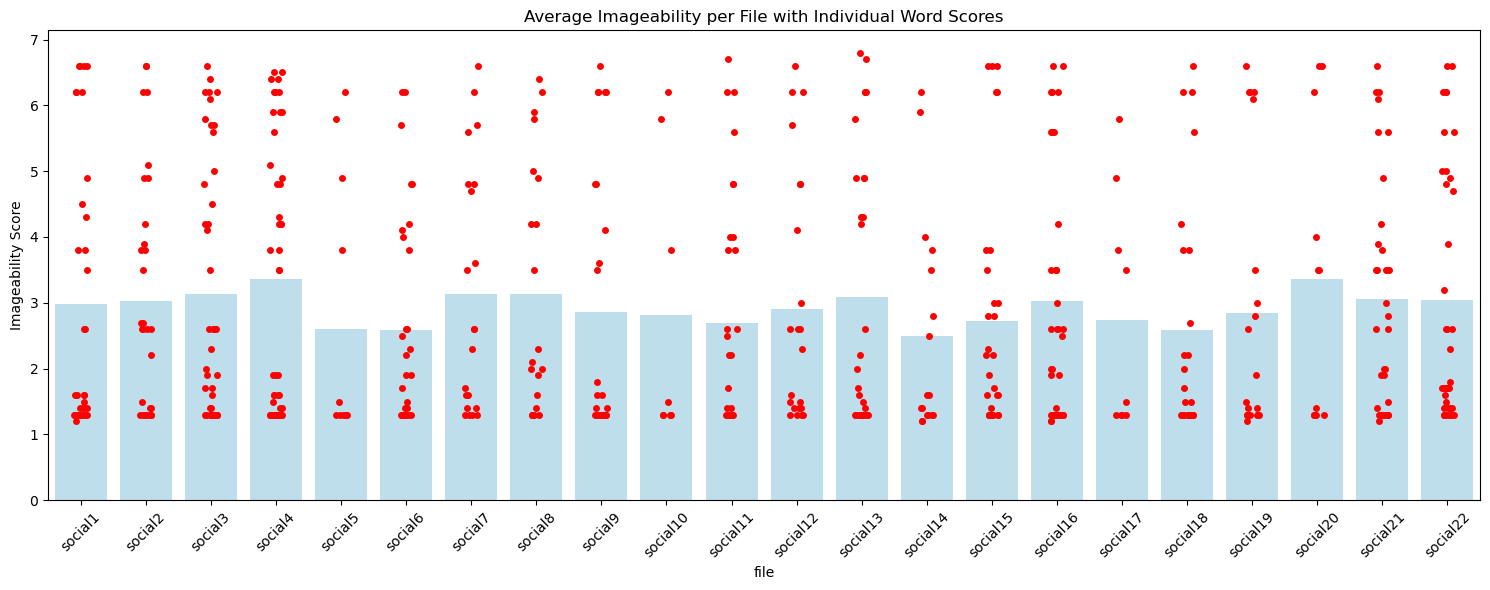

In [16]:
# Collect data
all_scores = []
mean_scores = []

for i in range(1, 23):
    filename = f"sub-049_time_sub49_social{i}.txt"
    file_path = os.path.join(folder_path, filename)
    scores = word_scores(file_path)
    mean_score = sum(scores)/len(scores) if scores else None
    
    # Store individual word scores 
    for score in scores:
        all_scores.append({"file": f"social{i}", "score": score})
    
    mean_scores.append({"file": f"social{i}", "mean_score": mean_score})

# Convert to DataFrames
df_scores = pd.DataFrame(all_scores)
df_mean = pd.DataFrame(mean_scores)

# Plot
plt.figure(figsize=(15,6))
sns.barplot(x="file", y="mean_score", data=df_mean, color="skyblue", alpha=0.6)
sns.stripplot(x="file", y="score", data=df_scores, color="red", size=5, jitter=True)
plt.xticks(rotation=45)
plt.ylabel("Imageability Score")
plt.title("Average Imageability per File with Individual Word Scores")
plt.tight_layout()
plt.savefig('plot1_imageability.png')

plt.show()


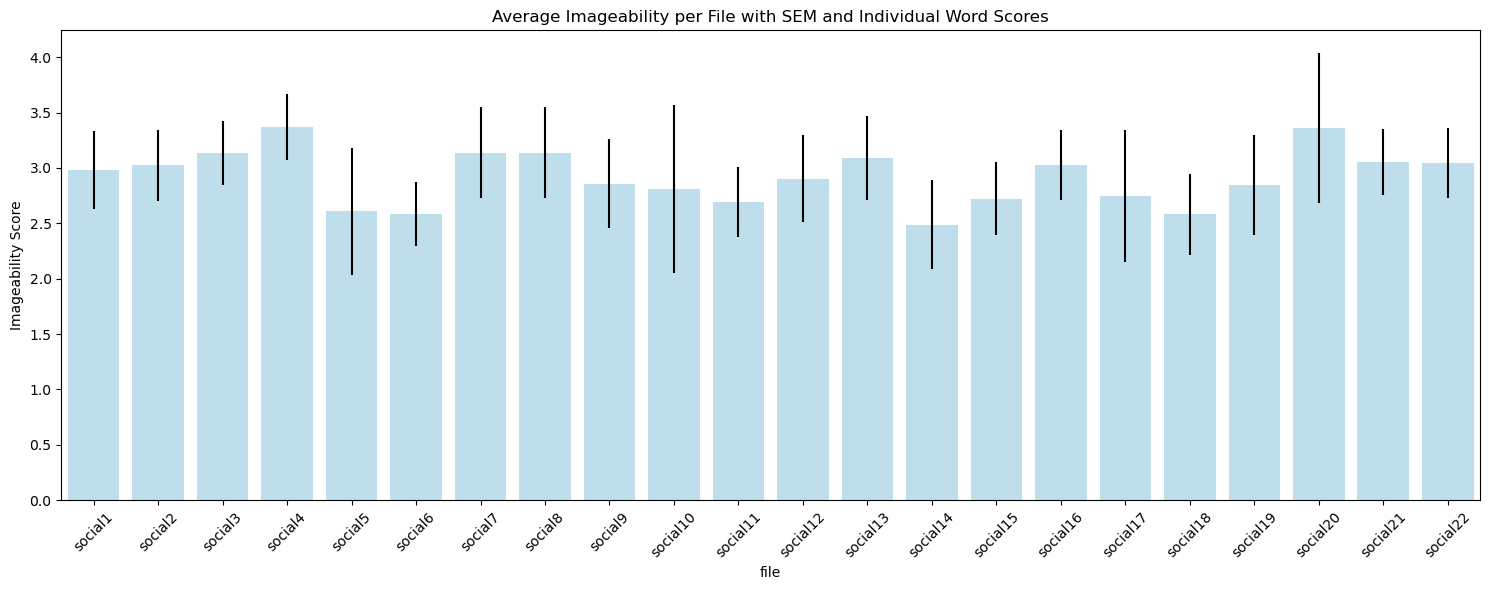

In [18]:
# Collect data
all_scores = []
mean_scores = []
sem_scores = []

for i in range(1, 23):
    filename = f"sub-049_time_sub49_social{i}.txt"
    file_path = os.path.join(folder_path, filename)
    scores = word_scores(file_path)
    
    if scores:
        mean_score = np.mean(scores)
        sem_score = np.std(scores, ddof=1) / np.sqrt(len(scores))  # Standard Error of the Mean
    else:
        mean_score = None
        sem_score = None
    
    # Store individual word scores with file label
    for score in scores:
        all_scores.append({"file": f"social{i}", "score": score})
    
    mean_scores.append({"file": f"social{i}", "mean_score": mean_score, "sem": sem_score})

# Convert to DataFrames
df_scores = pd.DataFrame(all_scores)
df_mean = pd.DataFrame(mean_scores)

# Plot
plt.figure(figsize=(15,6))

# Barplot with SEM as error bars
sns.barplot(x="file", y="mean_score", data=df_mean, color="skyblue", alpha=0.6, 
            yerr=df_mean["sem"])

# Overlay individual word scores
#sns.stripplot(x="file", y="score", data=df_scores, color="red", size=5, jitter=True)

plt.xticks(rotation=45)
plt.ylabel("Imageability Score")
plt.title("Average Imageability per File with SEM and Individual Word Scores")
plt.tight_layout()

plt.savefig('plot2_imageability.png')

plt.show()


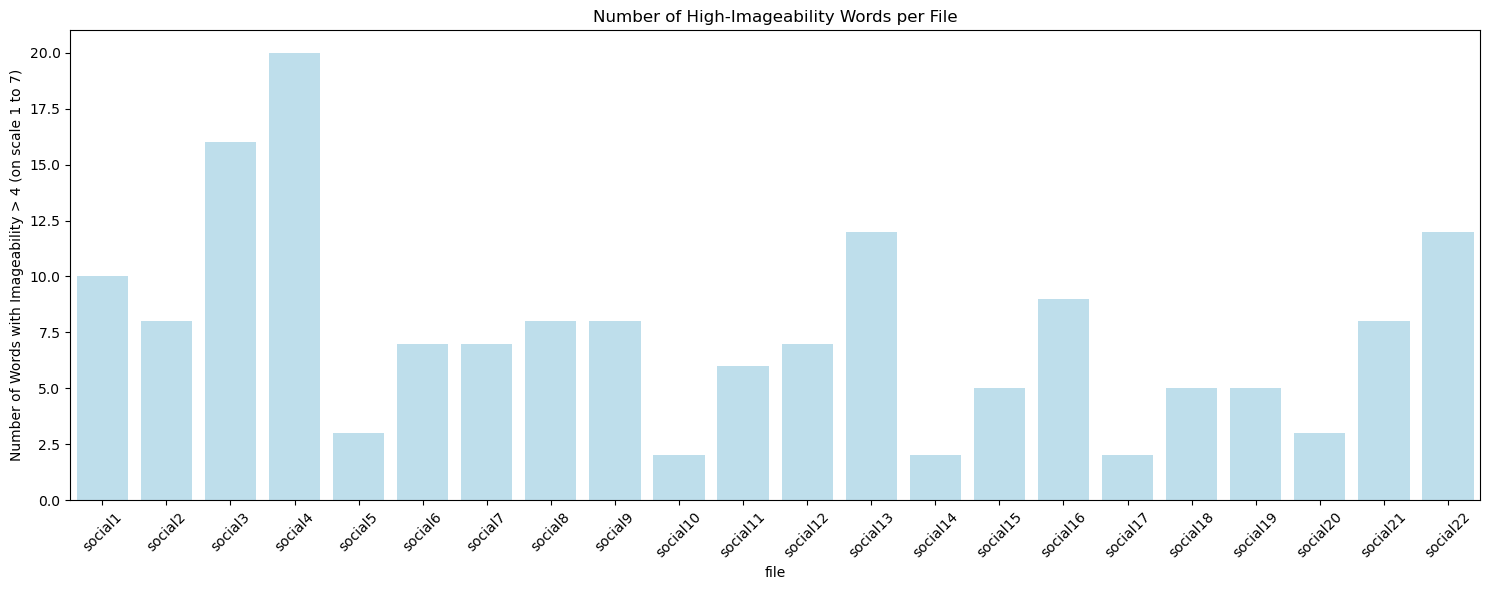

In [20]:
# Collect data
all_scores = []
high_score_counts = []

for i in range(1, 23):
    filename = f"sub-049_time_sub49_social{i}.txt"
    file_path = os.path.join(folder_path, filename)
    scores = word_scores(file_path)
    
    # Count words with score > 4
    count_high = sum(1 for s in scores if s > 4)
    
    # Store individual word scores for plotting
    for score in scores:
        all_scores.append({"file": f"social{i}", "score": score})
    
    high_score_counts.append({"file": f"social{i}", "count_high": count_high})

# Convert to DataFrames
df_scores = pd.DataFrame(all_scores)
df_counts = pd.DataFrame(high_score_counts)

# Plot

plt.figure(figsize=(15,6))

# Barplot: number of words with score > 4
sns.barplot(x="file", y="count_high", data=df_counts, color="skyblue", alpha=0.6)


plt.xticks(rotation=45)
plt.ylabel("Number of Words with Imageability > 4 (on scale 1 to 7)")
plt.title("Number of High-Imageability Words per File")
plt.tight_layout()

plt.savefig('plot3_imageability.png')


In [22]:
df_counts

,file,count_high
0,social1,10
1,social2,8
2,social3,16
3,social4,20
4,social5,3
5,social6,7
6,social7,7
7,social8,8
8,social9,8
9,social10,2


In [24]:
df_counts.to_csv("above4_imageability_results.csv", index=False)

In [43]:
# which words are imaginary evoking?
for i in [3,4,13,22]:
    filename = f"sub-049_time_sub49_social{i}.txt"
    file_path = os.path.join(folder_path, filename)

    print("segment: ",i )
    words = actual_words(file_path, imageability_dict)
    print()

segment:  3
boy: 6.2
two: 4.8
home: 5.7
roof: 6.4
home: 5.7
short: 4.5
chat: 4.2
boy: 6.2
son: 5.6
kiss: 6.1
him: 4.2
night: 5.8
boy: 6.2
back: 5.0
first: 4.1
bed: 6.6

segment:  4
boy: 6.2
dream: 4.9
sky: 6.5
huge: 4.2
bird: 6.4
boy: 6.2
can: 5.1
fly: 5.9
bird: 6.4
two: 4.8
soar: 4.3
sky: 6.5
boy: 6.2
two: 4.8
four: 5.9
boy: 6.2
flock: 5.6
him: 4.2
him: 4.2
fly: 5.9

segment:  13
third: 4.3
night: 5.8
boy: 6.2
dream: 4.9
dream: 4.9
boy: 6.2
him: 4.2
one: 4.9
arm: 6.8
boy: 6.2
reach: 4.3
feet: 6.7

segment:  22
boy: 6.2
two: 4.8
talk: 4.7
back: 5.0
boy: 6.2
ball: 6.6
friend: 5.6
boy: 6.2
ball: 6.6
friend: 5.6
back: 5.0
dream: 4.9

